## Steps:

1. Custom CNN for Feature Extraction
2. Texture Analysis using GLCM
3. Saving Features to CSV
4. Training an ANN Model
5. Model Evaluation Function

`
Note: we need to augment image 2000 image per class 
`

1388x1040 pixel RGB and .tif

In [1]:
# libs
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models
from skimage.feature import greycomatrix, greycoprops

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score

import os
from PIL import Image
import pickle

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
def save_model(model, file_path):
    """
    Saves the Model to a .pkl file.
    """
    with open(file_path, 'wb') as file:
        pickle.dump(model, file)
        
    print(f"Model saved to {file_path}")
    
def load_model(file_path):
    """
    Loads the model from a .pkl file. 
    """
    with open(file_path, 'rb') as file:
        model = pickle.load(file)
        
    print(f"Model loaded from {file_path}")
    
    return model

In [3]:
# Step 1: Custom CNN Model for Feature Extraction
def create_custom_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(2048, (3, 3), activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)

# Experiment failed
#     x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
#     x = layers.MaxPooling2D((2, 2))(x)
#     x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#     x = layers.MaxPooling2D((2, 2))(x)
#     x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
#     x = layers.MaxPooling2D((2, 2))(x)
#     x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
#     x = layers.MaxPooling2D((2, 2))(x)
#     x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
#     x = layers.MaxPooling2D((2, 2))(x)
#     x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#     x = layers.MaxPooling2D((2, 2))(x)
#     x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
#     x = layers.GlobalAveragePooling2D()(x)

    
    model = models.Model(inputs, x)
    
    model.summary()
    
    return model

In [4]:
# Step 2: Function to calculate GLCM properties
def calculate_glcm_features(image, distances, angles):
    properties = ['contrast', 'dissimilarity', 'homogeneity', 
                  'energy', 'correlation', 'ASM']
    glcm = greycomatrix(image, 
                        distances = distances, 
                        angles = angles,
#                         levels = 256,
                        symmetric = True, 
                        normed = True)
    feature_vector = []
    
    for prop in properties:
        prop_values = greycoprops(glcm, prop)
        feature_vector.extend(prop_values.flatten())
    
    return feature_vector

In [5]:
# Step 3: Fetch CNN features, GLCM features, and save to CSV
def extract_features_and_save(images, labels, cnn_model, output_csv, distances, angles):
    feature_list = []
    for i, image in enumerate(images):
        print(f"Processing image {i+1}/{len(images)}")
        
        # CNN Features
        image_expanded = np.expand_dims(image, axis=0)  # Expand dimensions for the CNN model
        cnn_features = cnn_model.predict(image_expanded).flatten()
        
        # GLCM Features
        image_gray = np.mean(image, axis=-1).astype(np.uint8)  # Convert to grayscale if needed
        glcm_features = calculate_glcm_features(image_gray, distances, angles)
        
        # Combine CNN + GLCM features
        combined_features = np.concatenate([cnn_features, glcm_features])
        feature_list.append(np.concatenate([combined_features, [int(labels[i])]]))
    
    # Create a DataFrame and save to CSV
    df = pd.DataFrame(feature_list)
#     df['col1'] = df['col1'].astype(int)
    df.to_csv(output_csv, index=False)
    print(f"Features saved to {output_csv}")

In [6]:
# Step 4: Create ANN model to train using extracted features
def create_ann_model(input_dim, num_class):
    model = models.Sequential([
        layers.Dense(1024, activation='relu', input_dim=input_dim),
        layers.Dense(256, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        #layers.Dense(num_class, activation='sigmoid')  # Adjust depending on the classification task (binary/multi-class)
        layers.Dense(num_class, activation='softmax')  # Adjust depending on the classification task (binary/multi-class)
    ])
    
    # model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # Adjust loss if multi-class
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])  # Adjust loss if multi-class
    
    model.summary()
    
    return model

In [7]:
# Step 5: Function to evaluate ANN model
def evaluate_model(model, X_test, y_test, class_names=None):
    #y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Binary thresholding for binary classification
    #print(classification_report(y_test, y_pred))
    y_pred = np.argmax(model.predict(X_test), axis=1)  # Get class with highest probability
    y_true = y_test # np.argmax(y_test, axis=1)  # Convert one-hot to labels for classification report
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Calculate accuracy score
    accuracy = accuracy_score(y_true, y_pred)
    
    # Get classification report
    class_report = classification_report(y_true, y_pred, target_names=class_names)
    
    # Calculate Cohen's kappa score
    kappa_score = cohen_kappa_score(y_true, y_pred)
    
    # Print evaluation metrics
    print(f"\nAccuracy Score: {accuracy * 100:.2f}%")
    print(f"Loss Score: {(1- accuracy) * 100:.2f}%")
    print(f"Cohen's Kappa Score: {kappa_score * 100:.4f}")
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", class_report)
    
    # Plot heatmap for confusion matrix
    plt.figure(figsize=(8, 6))
    try:
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    except Exception as e:
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix Heatmap')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()
    
#     print(classification_report(y_true, y_pred))

In [8]:
# Step 6: Load your dataset
# def load_dataset_from_directory(directory, img_size=(224, 224), batch_size=32):
#     dataset = tf.keras.utils.image_dataset_from_directory(
#         directory,
#         labels = 'inferred',
#         label_mode = 'categorical',  # 'int' for integer labels, change to 'categorical' if needed
#         image_size = img_size,  # Resize all images to the target size
#         batch_size = batch_size,
#         shuffle = True
#     )
    
#     return dataset

def load_dataset_from_directory(base_dir, image_size=(224, 224)):
    """
    Load images and labels from a directory.

    Args:
        base_dir (str): Path to the base directory containing class subdirectories.
        image_size (tuple): Target size to resize images (default: (128, 128)).

    Returns:
        tuple: (images, labels, class_names)
               - images: numpy array of images
               - labels: numpy array of labels
               - class_names: list of class names (ordered by directory names)
    """
    images = []
    labels = []
    class_names = sorted(os.listdir(base_dir))  # Class names sorted alphabetically
    
    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, class_name)
        
        if not os.path.isdir(class_dir):
            continue
        
        for file_name in os.listdir(class_dir):
            file_path = os.path.join(class_dir, file_name)
            try:
                # Open and preprocess the image
                img = Image.open(file_path).convert('RGB')  # Convert to RGB
                img = img.resize(image_size)  # Resize image to target size
                images.append(np.array(img))  # Convert image to numpy array
                labels.append(label)  # Append corresponding label
            except Exception as e:
                print(f"Error loading image {file_path}: {e}")
    
    # Convert lists to numpy arrays
    images = np.array(images, dtype='float32') / 255.0  # Normalize pixel values to [0, 1]
    labels = np.array(labels, dtype='int')

    return images, labels, class_names

In [9]:
# !pip install split-folders

# import os
# import splitfolders

# splitfolders.ratio(os.path.join('..', 'Dataset', 'Malignant_Lymphoma_Classification'),
#                    os.path.join('..', 'Dataset', 'Malignant_Lymphoma_Classification_data'),
#                    seed = 41,
#                    ratio = (0.6, 0.25, 0.15)) # train/val/test

Loaded 374 images.
Class names: ['CLL', 'FL', 'MCL']
Labels: [0 1 2]
Images of shape (224, 224, 3)
Loaded 374 labels
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d_7 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 112, 112, 32)      0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 56, 56, 64)        0         
 g2D)                                                            
        

E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0'

1/1 [==============================] - 0s 38ms/step
Processing image 5/374
1/1 [==============================] - 0s 37ms/step
Processing image 6/374
1/1 [==============================] - 0s 39ms/step
Processing image 7/374


E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0'

1/1 [==============================] - 0s 47ms/step
Processing image 8/374
1/1 [==============================] - 0s 39ms/step
Processing image 9/374
1/1 [==============================] - 0s 40ms/step
Processing image 10/374


...

E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0'

Processing image 373/374
1/1 [==============================] - 0s 37ms/step
Processing image 374/374
1/1 [==============================] - 0s 38ms/step


E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
E:\Projects\project_lymph\venv_ly\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0'

Features saved to ..\Dataset\CNN_GLCM_features.csv
X_train.shape[1] : 2054
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 1024)              2104320   
                                                                 
 dense_6 (Dense)             (None, 256)               262400    
                                                                 
 dense_7 (Dense)             (None, 64)                16448     
                                                                 
 dense_8 (Dense)             (None, 32)                2080      
                                                                 
 dense_9 (Dense)             (None, 3)                 99        
                                                                 
Total params: 2385347 (9.10 MB)
Trainable params: 2385347 (9.10 MB)
Non-trainable params: 0 (0.00 Byte)
_______

Epoch 51/100
9/9 [==============================] - 0s 13ms/step - loss: 0.9337 - accuracy: 0.4907 - val_loss: 0.8815 - val_accuracy: 0.5333
Epoch 52/100
9/9 [==============================] - 0s 13ms/step - loss: 0.9329 - accuracy: 0.5093 - val_loss: 0.9497 - val_accuracy: 0.5000
Epoch 53/100
9/9 [==============================] - 0s 13ms/step - loss: 0.9568 - accuracy: 0.5019 - val_loss: 0.8891 - val_accuracy: 0.5667
Epoch 54/100
9/9 [==============================] - 0s 13ms/step - loss: 0.9499 - accuracy: 0.4981 - val_loss: 0.8863 - val_accuracy: 0.5667
Epoch 55/100
9/9 [==============================] - 0s 13ms/step - loss: 0.9281 - accuracy: 0.5204 - val_loss: 0.8979 - val_accuracy: 0.6000
Epoch 56/100
9/9 [==============================] - 0s 13ms/step - loss: 0.9020 - accuracy: 0.5390 - val_loss: 0.9720 - val_accuracy: 0.5000
Epoch 57/100
9/9 [==============================] - 0s 12ms/step - loss: 0.9656 - accuracy: 0.4796 - val_loss: 0.8921 - val_accuracy: 0.5667
Epoch 58/100


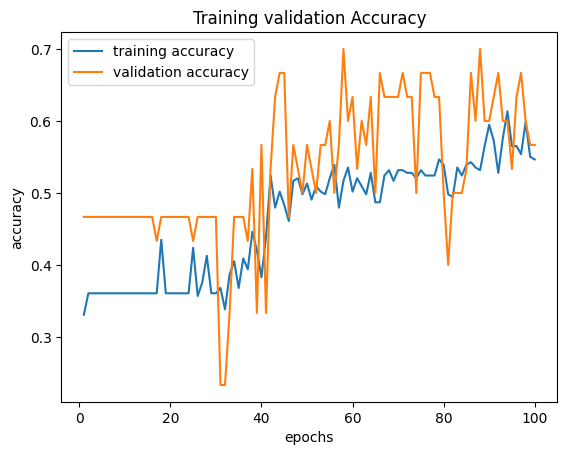

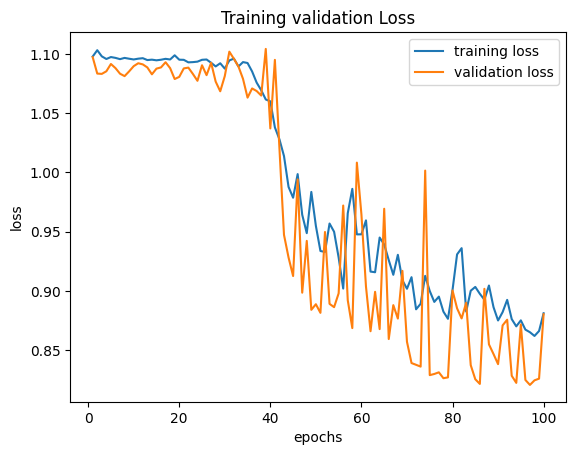

3/3 [==============================] - 0s 3ms/step

Accuracy Score: 57.33%
Loss Score: 42.67%
Cohen's Kappa Score: 34.5692
Confusion Matrix:
 [[13  7  3]
 [ 0 27  1]
 [10 11  3]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.57      0.57      0.57        23
         1.0       0.60      0.96      0.74        28
         2.0       0.43      0.12      0.19        24

    accuracy                           0.57        75
   macro avg       0.53      0.55      0.50        75
weighted avg       0.53      0.57      0.51        75



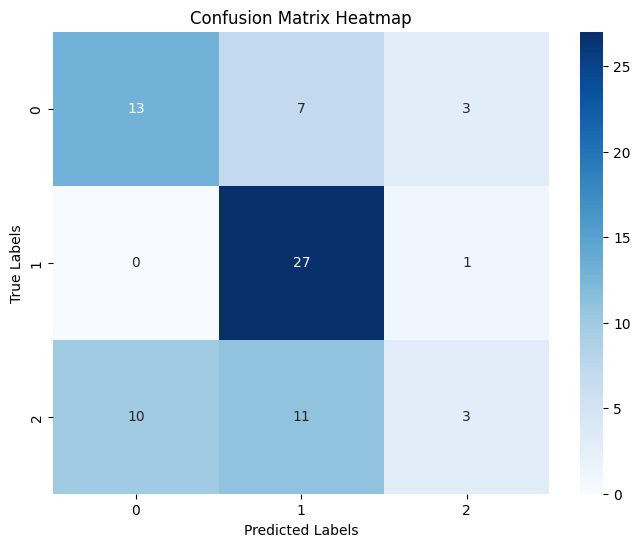

In [11]:
if __name__ == "__main__":
    CNN_MODEL = os.path.join('..', 'Models_part2', 'cnn_model.pkl')
    ANN_MODEL = os.path.join('..', 'Models_part2', 'ann_model.pkl')
    
    # Step 6: Load your dataset
    # Load training data
    train_directory = os.path.join('..', 'Dataset', 'Malignant_Lymphoma_Classification')
    images, labels, class_names = load_dataset_from_directory(train_directory, image_size=(224, 224))
    print(f"Loaded {len(images)} images.")
    print(f"Class names: {class_names}")
    print(f"Labels: {np.unique(labels)}")    
    print(f"Images of shape {images.shape[1:]}")
    print(f"Loaded {labels.shape[0]} labels")

    # Step 7: CNN Model for feature extraction
    cnn_model = create_custom_cnn(input_shape=(224, 224, 3))
    
    # Save model
    save_model(cnn_model, CNN_MODEL)
    
    # Step 8: GLCM parameters
    distances = [1] # [1, 3, 5, 3, 1, 3, 5]
    angles = [0] # [0, 0, 0, np.pi/4, np.pi/2, np.pi/2, np.pi/2]

    # Step 9: Extract features and save to CSV
    output_csv = os.path.join('..', 'Dataset', 'CNN_GLCM_features.csv')
    extract_features_and_save(images, labels, cnn_model, output_csv, distances, angles)

    # Step 10: Load CSV and prepare for ANN training
    data = pd.read_csv(output_csv)
    
    X = data.iloc[:, :-1].values  # All columns except the last one (features)
    y = data.iloc[:, -1].values  # Last column (labels)
#     print(X, y)
    
    # Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"X_train.shape[1] : {X_train.shape[1]}")
    
    # Step 11: Create and train ANN
    ann_model = create_ann_model(input_dim=X_train.shape[1], num_class=len(class_names))
    history = ann_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)
    
    # Save model
    save_model(ann_model, ANN_MODEL)
    
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.plot(epochs, acc, label='training accuracy')
    plt.plot(epochs, val_acc, label='validation accuracy')
    plt.legend()
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.title('Training validation Accuracy')
    plt.show()

    plt.plot(epochs, loss, label='training loss')
    plt.plot(epochs, val_loss, label='validation loss')
    plt.legend()
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.title('Training validation Loss')
    plt.show()

    # Step 12: Evaluate the model
    evaluate_model(ann_model, X_test, y_test)

    